 Calcule la TDF de una imagen, obtenga magnitud y fase.
Genere una imagen reconstruida s´olo con la magnitud considerando fase cero
y genere otra imagen reconstruida usando s´olo fase de la imagen considerando
magnitud unitaria.
Visualice las im´agenes y saque conclusiones sobre el aporte de ambas componentes a la reconstrucci´on de la imagen.
2. Reproduzca el experimento de Openheim utilizando las im´agenes puente.jpg
y ferrari-c.png. Visualice y comente los resultados

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def graph_fft_3d(width, height, magnitude):
    x = np.arange(width)
    y = np.arange(height)
    X, Y = np.meshgrid(x, y)

    fig = go.Figure(
        data=[
            go.Surface(
                z=magnitude,
                x=X,
                y=Y
            )
        ]
    )

    fig.update_layout(
        title="Magnitud de la FFT (3D)",
        scene=dict(
            xaxis_title="Frecuencia X",
            yaxis_title="Frecuencia Y",
            zaxis_title="Magnitud"
        ),
        width=800,
        height=700
    )

    fig.show()
    

# Experimento de oppenheimer!!!
Ver la importancia de la magnitud y la fase en la reconstrucción de la imagen.

## analisis puente

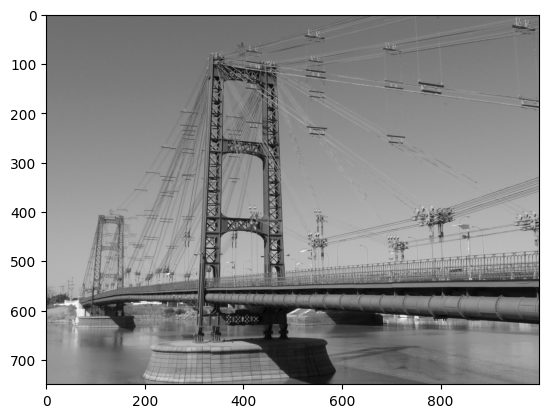

In [7]:
# cargamos la imagen

img = cv2.imread("../Imagenes_cursado/puente.jpg",cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.show()

las tdf devuelve numeros de la forma a + jb. la fase se calcula como arctan(b/a)

para la reconstruccion

In [ ]:
# hacemos la transformada y vemos que onda

fft = np.fft.fft2(img) #son numeros complejos de la forma a + jb

magnitude = np.abs(fft)
fase = np.angle(fft) #me da angulos reales, pero lo necesito pasarlo a complejo



#reconstruccion utilizando la magnitud

img_only_mod = np.fft.ifft2(magnitude)
img_only_fase = np.fft.ifft2(np.exp(1j*fase))


plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Imagen original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(np.log(1 + ), cmap='gray')
plt.title("Magnitud FFT (log)")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(img_only_mag, cmap='gray')
plt.title("Reconstrucción SOLO magnitud")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(img_only_phase, cmap='gray')
plt.title("Reconstrucción SOLO fase")
plt.axis("off")

plt.tight_layout()
plt.show()